## Generate predictions from models

### Import packages 

In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
tfkl = tf.keras.layers
import pandas as pd
from scipy.stats import linregress

### Import functions

In [23]:
import evaluation_functions
import importlib
importlib.reload(evaluation_functions)

<module 'evaluation_functions' from '/Users/paigepark/Desktop/repos/deep-mort/code/evaluation_functions.py'>

### Import data

In [24]:
state_training = np.loadtxt('../data/state_training_orig.txt')
state_test = np.loadtxt('../data/state_test_orig.txt')

In [25]:
country_training = np.loadtxt('../data/country_training_orig.txt')
country_test = np.loadtxt('../data/country_test_orig.txt')

In [26]:
combined_training = np.loadtxt('../data/combined_training_orig.txt')
combined_test = np.loadtxt('../data/combined_test_orig.txt')

In [27]:
geos_key = np.load('../data/geos_key.npy')
geo_dict = {int(code): geo for geo, code in geos_key}

In [28]:
# convert actual test data to log scale
country_test[:,4][country_test[:,4] == 0] = 9e-06
country_test[:,4] = np.log(country_test[:,4])

In [29]:
# convert actual test data to log scale
combined_test[:,4][combined_test[:,4] == 0] = 9e-06
combined_test[:,4] = np.log(combined_test[:,4])

### Import predictions

In [30]:
# DL predictions - trained on all countries
dl_test_pred = []
for i in range(1,6):
    dl_test_pred.append(np.loadtxt(f"../data/dl_country_forecast_{i}.txt"))

# LC predictions
lc_test_pred = np.loadtxt("../data/lc_forecast.csv", delimiter=",", usecols=(0, 1, 2, 3, 4))
lc_test_pred = lc_test_pred[np.lexsort((lc_test_pred[:, 1], lc_test_pred[:, 3], lc_test_pred[:, 2], lc_test_pred[:, 0]))]
lc_test_pred[:,4][lc_test_pred[:,4] == 0] = 9e-06
lc_test_pred[:,4] = np.log(lc_test_pred[:,4])

# hyndman-ullah predictions
hu_test_pred = np.loadtxt("../data/hu_forecast.csv", delimiter=",", usecols=(0, 1, 2, 3, 4))
hu_test_pred = hu_test_pred[np.lexsort((hu_test_pred[:, 1], hu_test_pred[:, 3], hu_test_pred[:, 2], hu_test_pred[:, 0]))]
hu_test_pred[:,4][hu_test_pred[:,4] == 0] = 9e-06
hu_test_pred[:,4] = np.log(hu_test_pred[:,4])

# coherent predictions
c_test_pred = np.loadtxt("../data/coherent_forecast.csv", delimiter=",", usecols=(0, 1, 2, 3, 4))
c_test_pred = c_test_pred[np.lexsort((c_test_pred[:, 1], c_test_pred[:, 3], c_test_pred[:, 2], c_test_pred[:, 0]))]
c_test_pred[:,4][c_test_pred[:,4] == 0] = 9e-06
c_test_pred[:,4] = np.log(c_test_pred[:,4])

# DL predictions - trained on all countries and states
combined_test_pred = []
for i in range(1,6):
    combined_test_pred.append(np.loadtxt(f"../data/dl_combined_forecast_{i}.txt"))

In [31]:
geo_dict_countries_only = dict(list(geo_dict.items())[-40:])

In [32]:
# loading in single country / single gender predictions 
single_preds_combined = []

for j in range(1,6):
    preds_for_iter = []
    for geo in geo_dict_countries_only.values():
        for gender in range(2):
            single_pred = np.load(f"../data/single_preds/{geo}_gender_{gender}_iter_{j}.npz")
            arr = list(single_pred.values())[0]
            preds_for_iter.append(arr)

    combined_array = np.vstack(preds_for_iter)
    
    single_preds_combined.append(combined_array)


Prep data

In [33]:
actual_data_divided = []
actual_combined_divided = []
dl_test_divided = [[] for _ in range(5)]
combined_test_divided = [[] for _ in range(5)]
single_test_divided = [[] for _ in range(5)]
lc_test_divided = []
hu_test_divided = []
c_test_divided = []

for j in range(5):
    for i in range(90):
        actual_combined_divided.append(combined_test[combined_test[:,0] == i])
        combined_test_divided[j].append(combined_test_pred[j][combined_test_pred[j][:, 0] == i])

for j in range(5):
    for i in range(50,90):
        actual_data_divided.append(country_test[country_test[:, 0] == i])
        dl_test_divided[j].append(dl_test_pred[j][dl_test_pred[j][:, 0] == i])
        single_test_divided[j].append(single_preds_combined[j][single_preds_combined[j][:, 0] == i])

# LC, HU, and Coherent are single deterministic forecasts (no seed dimension)
for i in range(50,90):
    lc_test_divided.append(lc_test_pred[lc_test_pred[:, 0] == i])
    hu_test_divided.append(hu_test_pred[hu_test_pred[:, 0] == i])
    c_test_divided.append(c_test_pred[c_test_pred[:, 0] == i])

# Figures in Paper

### Overall performance (Figure 1)

In [34]:
dl_all = []
single_all = []

# LC, HU, and Coherent are single deterministic forecasts (no seed dimension)
lc_by_country = []
hu_by_country = []
coh_by_country = []
for i in range(0,40):
    lc_mse_overall, lc_rmse_overall, lc_rrmse_overall = evaluation_functions.calculate_error(lc_test_divided[i], actual_data_divided[i])
    hu_mse_overall, hu_rmse_overall, hu_rrmse_overall = evaluation_functions.calculate_error(hu_test_divided[i], actual_data_divided[i])
    coh_mse_overall, coh_rmse_overall, coh_rrmse_overall = evaluation_functions.calculate_error(c_test_divided[i], actual_data_divided[i])
    lc_by_country.append(lc_mse_overall)
    hu_by_country.append(hu_mse_overall)
    coh_by_country.append(coh_mse_overall)

lc_ave_by_country = np.array(lc_by_country)
hu_ave_by_country = np.array(hu_by_country)
coh_ave_by_country = np.array(coh_by_country)

# DL models vary across the 5 seeds, so average over them
for j in range(5):
    dl_mse_results_by_country = []
    single_mse_results_by_country = []
    for i in range(0,40):
        dl_mse_overall, dl_rmse_overall, dl_rrmse_overall = evaluation_functions.calculate_error(dl_test_divided[j][i], actual_data_divided[i])
        single_mse_overall, single_rmse_overall, single_rrmse_overall = evaluation_functions.calculate_error(single_test_divided[j][i], actual_data_divided[i]) 
        
        dl_mse_results_by_country.append(dl_mse_overall)
        single_mse_results_by_country.append(single_mse_overall)

    dl_all.append(np.array(dl_mse_results_by_country))
    single_all.append(np.array(single_mse_results_by_country))

In [35]:
# average mses by country
# lc/hu/coh are deterministic and already computed above
dl_ave_by_country = sum(dl_all) / len(dl_all)
single_ave_by_country = sum(single_all) / len(single_all)

In [36]:
lc_overall = []
hu_overall = []
coh_overall = []
dl_overall = []
single_overall = []

# LC, HU, and Coherent are single deterministic forecasts (no seed dimension)
lc_overall_ave, lc_rmse_overall, lc_rrmse_overall = evaluation_functions.calculate_error(lc_test_pred, country_test)
hu_overall_ave, hu_rmse_overall, hu_rrmse_overall = evaluation_functions.calculate_error(hu_test_pred, country_test)
coh_overall_ave, coh_rmse_overall, coh_rrmse_overall = evaluation_functions.calculate_error(c_test_pred, country_test)

# DL models vary across the 5 seeds, so average over them
for i in range(5):    
    dl_mse_overall, dl_rmse_overall, dl_rrmse_overall = evaluation_functions.calculate_error(dl_test_pred[i], country_test)
    single_mse_overall, single_rmse_overall, single_rrmse_overall = evaluation_functions.calculate_error(single_preds_combined[i], country_test)

    dl_overall.append(dl_mse_overall)
    single_overall.append(single_mse_overall)

dl_overall_ave = sum(dl_overall) / len(dl_overall)
single_overall_ave = sum(single_overall) / len(single_overall)

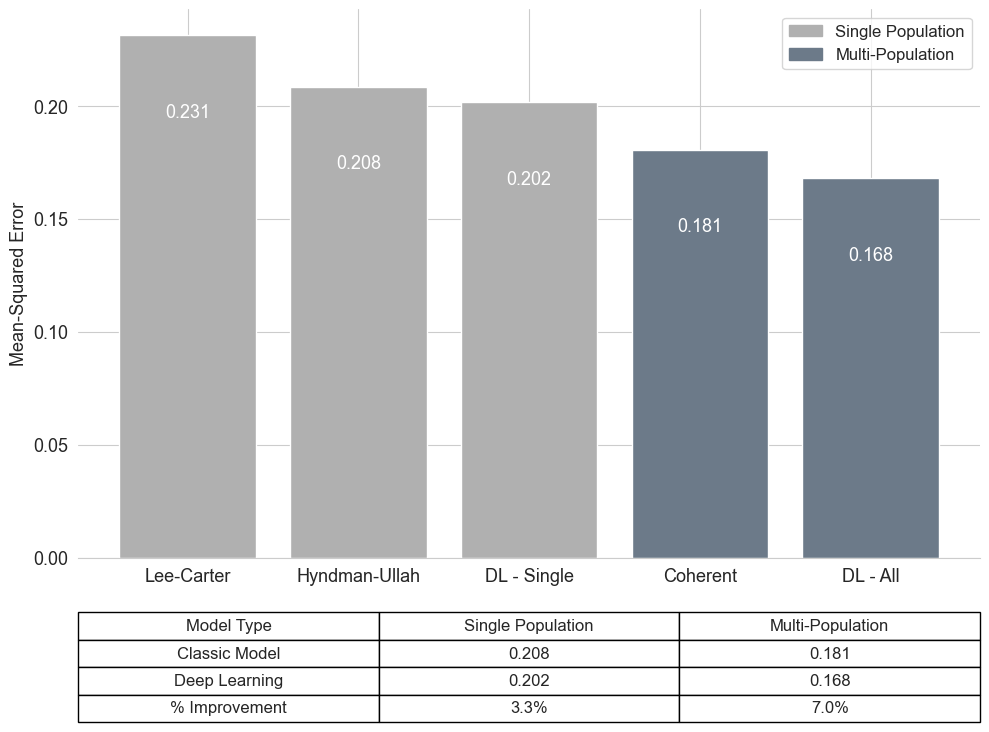

In [52]:
# data
from matplotlib import patches


overalls = np.array([lc_overall_ave, hu_overall_ave, single_overall_ave, coh_overall_ave, dl_overall_ave])
labels = ['Lee-Carter', 'Hyndman-Ullah', 'DL - Single', 'Coherent', 'DL - All']

# Define bar colors: light gray for single-country, darker gray-blue for multi-country
bar_colors = ['#B0B0B0', '#B0B0B0', '#B0B0B0', '#6C7A89', '#6C7A89']  # Soft neutral tones

# Create the plot
fig, ax = plt.subplots(figsize=(10, 7))
#fig.patch.set_facecolor('white')

bars = ax.bar(labels, overalls, color=bar_colors)

# Clean axes
#ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False, bottom=False, labelsize=13)

# Bar labels
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval - 0.03,
        f'{yval:.3f}',
        ha='center',
        va='top',
        fontsize=13,
        color='white' if yval > 0.15 else 'black'
    )

# Legend with neutral tones
legend_handles = [
    patches.Patch(color='#B0B0B0', label='Single Population'),
    patches.Patch(color='#6C7A89', label='Multi-Population')
]
ax.legend(handles=legend_handles, fontsize=12, loc='upper right')

# Final labels
ax.set_ylabel('Mean-Squared Error', fontsize=13)
ax.set_xlabel('')

# percent improvement of deep learning over the classic model
pct_impr1 = (hu_overall_ave - single_overall_ave) / hu_overall_ave * 100
pct_impr2 = (coh_overall_ave - dl_overall_ave) / coh_overall_ave * 100

# Add table
table_data = [
    ['Classic Model', f'{hu_overall_ave:.3f}', f'{coh_overall_ave:.3f}'],
    ['Deep Learning', f'{single_overall_ave:.3f}', f'{dl_overall_ave:.3f}'],
    ['% Improvement', f'{pct_impr1:.1f}%', f'{pct_impr2:.1f}%']
]
column_labels = ['Model Type', 'Single Population', 'Multi-Population']

table = plt.table(
    cellText=table_data,
    colLabels=column_labels,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.3, 1, 0.2]
)
table.auto_set_font_size(False)
table.set_fontsize(12)

plt.subplots_adjust(left=0.1, bottom=0.3)
plt.tight_layout()
plt.savefig("../figures/overall_barplot_with_table_jun.png", format="png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### Results by country (Table 1)

In [39]:
overalls = np.array([lc_overall_ave, hu_overall_ave, single_overall_ave, coh_overall_ave, dl_overall_ave])
labels = ['Lee-Carter', 'Hyndman-Ullah', 'Single Population DL', 'Coherent', 'All Country DL']

In [40]:
mse_results_by_country = np.column_stack((lc_ave_by_country, hu_ave_by_country, single_ave_by_country, coh_ave_by_country, dl_ave_by_country))

In [41]:
new_mses = np.vstack([mse_results_by_country, overalls])

In [42]:
# add a row to geos_key for overall mses
geos_key
new = np.array([["Overall", 90]])
geos_key_with_overall = np.vstack([geos_key, new])

In [43]:
# change geo abbreviations to full name for table
full_names_mapping = {
    # US states
    'AK': 'Alaska', 'AL': 'Alabama', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'IA': 'Iowa', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas', 'KY': 'Kentucky',
    'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland', 'MA': 'Massachusetts',
    'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire',
    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon',
    'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina', 'SD': 'South Dakota',
    'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',

    # Countries
    'AUS': 'Australia', 'AUT': 'Austria', 'BEL': 'Belgium', 'BGR': 'Bulgaria', 'BLR': 'Belarus',
    'CAN': 'Canada', 'CHE': 'Switzerland', 'CZE': 'Czech Republic', 'DNK': 'Denmark', 'DEUTE': 'East Germany',
    'DEUTW': 'West Germany',
    'ESP': 'Spain', 'EST': 'Estonia', 'FIN': 'Finland', 'FRATNP': 'France',
    'GBRTENW': 'England and Wales', 'GBR_NIR': 'Northern Ireland',
    'GBR_SCO': 'Scotland', 'GRC': 'Greece', 'HUN': 'Hungary', 'IRL': 'Ireland',
    'ISL': 'Iceland', 'ISR': 'Israel', 'ITA': 'Italy', 'JPN': 'Japan', 'LTU': 'Lithuania',
    'LUX': 'Luxembourg', 'LVA': 'Latvia', 'NLD': 'Netherlands', 'NOR': 'Norway',
    'NZL_NP': 'New Zealand', 'POL': 'Poland', 'PRT': 'Portugal', 'RUS': 'Russia',
    'SVK': 'Slovakia', 'SVN': 'Slovenia', 'SWE': 'Sweden', 'TWN': 'Taiwan',
    'UKR': 'Ukraine', 'USA': 'United States', 'NZL_NM': 'New Zealand',
    'Overall': 'Overall'
}

# Convert existing array
geos_key_full_names = np.array([
    [full_names_mapping.get(code, code), idx] for code, idx in geos_key_with_overall
])

In [44]:
percent_improvement_all_countries = []
for i in range(0,len(np.unique(country_training[:,0]))+1):
    val = (1 - new_mses[i][4] / new_mses[i][3]) * 100
    percent_improvement_all_countries.append(val)


In [45]:
mses_with_percent_imp = np.column_stack((new_mses, percent_improvement_all_countries))

In [46]:
# create a DataFrame
df_mse = pd.DataFrame(
    mses_with_percent_imp,
    columns=['LC', 'HU', 'DL Single', 'Coherent', 'DL All', "\% Impr. DL vs Coherent"],
    index=[geos_key_full_names[i+50, 0] for i in range(len(new_mses))]
)

# raw difference between DL All and Coherent (Coherent - DL All)
df_mse.insert(
    df_mse.columns.get_loc("\% Impr. DL vs Coherent"),
    "Coherent - DL All",
    df_mse["Coherent"] - df_mse["DL All"]
)

# round
df_mse = df_mse.round(3)


# sort by the last column in descending order
df_data = df_mse.iloc[:-1]
df_overall = df_mse.iloc[-1:]
df_data_sorted = df_data.sort_values(by="\% Impr. DL vs Coherent", ascending=False)

# concatenate the sorted data with the overall row at the end
df_final = pd.concat([df_data_sorted, df_overall])

# convert the DataFrame to a LaTeX formatted table
latex_table = df_final.to_latex(index=True, float_format="%.3f")

# display the LaTeX code
print(latex_table)


\begin{tabular}{lrrrrrrr}
\toprule
 & LC & HU & DL Single & Coherent & DL All & Coherent - DL All & \% Impr. DL vs Coherent \\
\midrule
Ukraine & 0.083 & 0.086 & 0.058 & 0.050 & 0.025 & 0.024 & 48.986 \\
Spain & 0.091 & 0.073 & 0.049 & 0.066 & 0.049 & 0.016 & 24.884 \\
Hungary & 0.202 & 0.114 & 0.068 & 0.080 & 0.062 & 0.018 & 22.988 \\
Finland & 0.151 & 0.140 & 0.139 & 0.136 & 0.113 & 0.022 & 16.561 \\
Switzerland & 0.137 & 0.123 & 0.100 & 0.122 & 0.103 & 0.019 & 15.711 \\
Belgium & 0.063 & 0.062 & 0.057 & 0.054 & 0.046 & 0.007 & 13.641 \\
Slovenia & 0.699 & 0.616 & 0.662 & 0.538 & 0.467 & 0.071 & 13.178 \\
Ireland & 0.140 & 0.138 & 0.122 & 0.122 & 0.106 & 0.016 & 12.885 \\
Australia & 0.040 & 0.036 & 0.027 & 0.030 & 0.027 & 0.003 & 11.581 \\
England and Wales & 0.024 & 0.019 & 0.017 & 0.023 & 0.021 & 0.003 & 11.329 \\
Austria & 0.074 & 0.068 & 0.067 & 0.070 & 0.063 & 0.007 & 10.211 \\
Estonia & 0.812 & 0.707 & 0.623 & 0.552 & 0.495 & 0.056 & 10.169 \\
Bulgaria & 0.084 & 0.085 & 0.057 

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:10: SyntaxWarning: invalid escape sequence '\%'
<>:22: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:10: SyntaxWarning: invalid escape sequence '\%'
<>:22: SyntaxWarning: invalid escape sequence '\%'
/var/folders/9w/c0r00l9s0hschsd5nsg179tm0000gn/T/ipykernel_85354/4168604401.py:4: SyntaxWarning: invalid escape sequence '\%'
  columns=['LC', 'HU', 'DL Single', 'Coherent', 'DL All', "\% Impr. DL vs Coherent"],
/var/folders/9w/c0r00l9s0hschsd5nsg179tm0000gn/T/ipykernel_85354/4168604401.py:10: SyntaxWarning: invalid escape sequence '\%'
  df_mse.columns.get_loc("\% Impr. DL vs Coherent"),
/var/folders/9w/c0r00l9s0hschsd5nsg179tm0000gn/T/ipykernel_85354/4168604401.py:22: SyntaxWarning: invalid escape sequence '\%'
  df_data_sorted = df_data.sort_values(by="\% Impr. DL vs Coherent", ascending=False)


### Top performers (Figure 3)

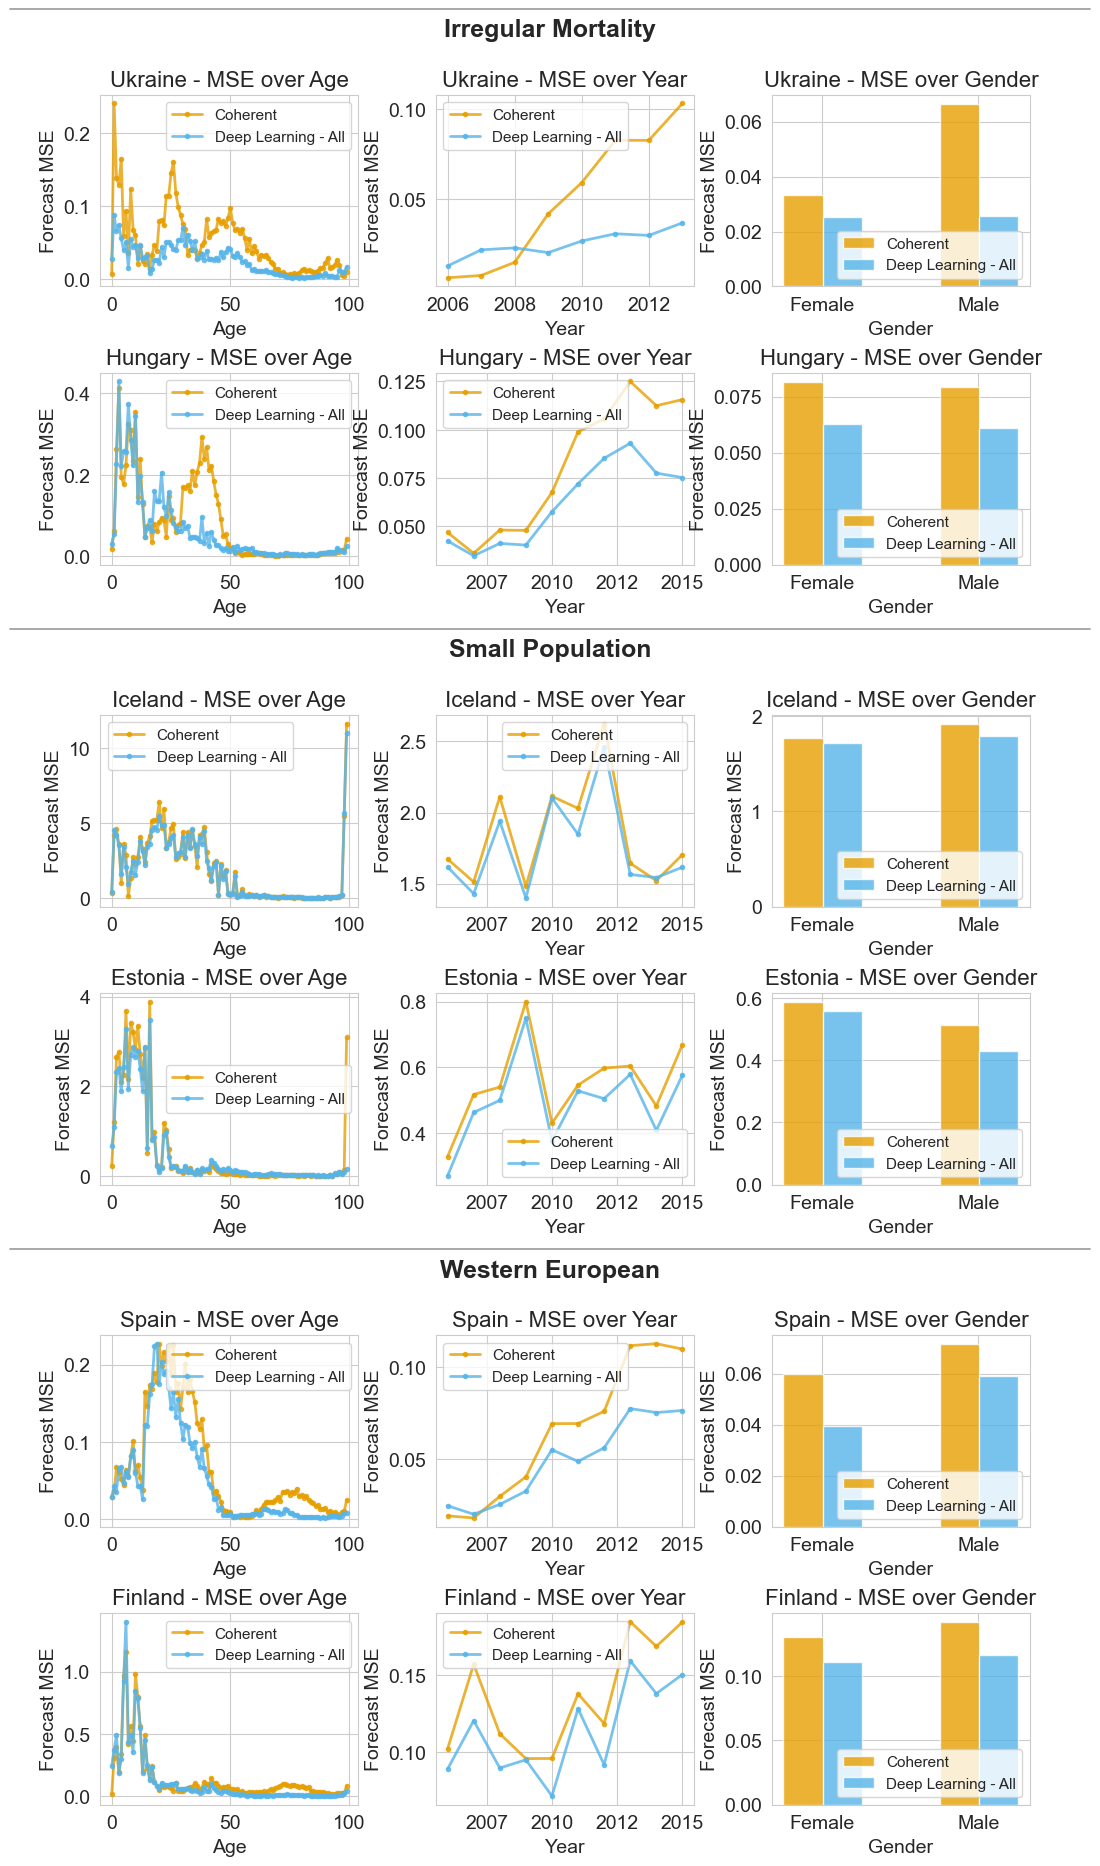

In [53]:
# Simple top performer / US figures 
sns.set_style("whitegrid")
palette = ["#E69F00", "#56B4E9", "#009E73"]  # orange, sky blue, green
from matplotlib.lines import Line2D



def compute_avg_mses(country_index, feature_index, models):
    avg_mses = {}

    # Each model maps to a list of replicates: 5 for the seed-varying DL models,
    # a single replicate for the deterministic LC/HU/Coherent models.
    for label, replicates in models.items():
        ci = country_index
        actual = actual_data_divided
        if label == "DL - Countries & States":
           ci = country_index + 50
           actual = actual_combined_divided
        mse_list = []
        for rep in replicates:
            mse, _, _ = evaluation_functions.calculate_error_by_category(
                rep[ci],
                actual[ci],
                feature_index=feature_index
            )
            mse_list.append(mse)

        combined = {}
        for d in mse_list:
            for k, v in d.items():
                if k not in combined:
                    combined[k] = [v, 1]
                else:
                    combined[k][0] += v
                    combined[k][1] += 1
        avg_mses[label] = {k: total / count for k, (total, count) in combined.items()}

    return avg_mses

# build a lookup from country name to its index in the divided arrays.
# geos_key stores [abbreviation, code]; the divided arrays are indexed by code - 50.
name_to_index = {full_names_mapping.get(abbrev, abbrev): int(code) - 50 for abbrev, code in geos_key}

# countries grouped into categories; each group of two countries gets a header
# and a visual break separating it from the next group
groups = [
    ("Irregular Mortality", ["Ukraine", "Hungary"]),
    ("Small Population", ["Iceland", "Estonia"]),
    ("Western European", ["Spain", "Finland"]),
]
features = {"Age": 3, "Year": 2, "Gender": 1}  
models = {"Coherent": [c_test_divided], "Deep Learning - All": dl_test_divided}

fig = plt.figure(figsize=(12, 19))
outer = fig.add_gridspec(len(groups), 1, top=0.94, bottom=0.04, hspace=0.32)

for g_idx, (group_label, group_countries) in enumerate(groups):
    # 2 countries x 3 features within each group, packed tightly together
    inner = outer[g_idx].subgridspec(2, 3, hspace=0.45, wspace=0.3)

    # group header (and divider rule) placed in the gap above the block
    pos = outer[g_idx].get_position(fig)
    fig.add_artist(Line2D([0.05, 0.95], [pos.y1 + 0.045, pos.y1 + 0.045],
                          color="0.6", linewidth=1.2))
    fig.text(0.5, pos.y1 + 0.028, group_label, ha="center", va="bottom",
             fontsize=18, fontweight="bold")

    for r, country_name in enumerate(group_countries):
        country_index = name_to_index[country_name]
        for jdx, (feature_name, feature_index) in enumerate(features.items()):
            ax = fig.add_subplot(inner[r, jdx])
            avg_mses = compute_avg_mses(country_index, feature_index, models)

            for i, (label, data) in enumerate(avg_mses.items()):
                keys, values = zip(*sorted(data.items()))

                if feature_index == 1:  
                    x = np.arange(len(keys)) + i * 0.25 
                    ax.bar(x, values, width=0.25, label=label, alpha=0.8, color=palette[i])
                    gender_labels = ['Female' if k == 0 else 'Male' for k in keys]
                    ax.set_xticks(np.arange(len(keys)) + 0.12)
                    ax.set_xticklabels(gender_labels)
                    ax.legend(fontsize=11, loc='lower right', frameon=True)
                else:
                    ax.plot(keys, values, label=label, linestyle='-', marker='o',
                            markersize=3, linewidth=2, alpha=0.8, color=palette[i])
                    ax.legend(fontsize=11, loc='best', frameon=True)
                    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

            ax.set_title(f"{country_name} - MSE over {feature_name}")
            ax.set_xlabel(feature_name)
            ax.set_ylabel("Forecast MSE")
        

plt.savefig("../figures/top_6x3_jun.png", format="png", dpi=300, bbox_inches="tight")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})
plt.show()

### US (Figure 4)

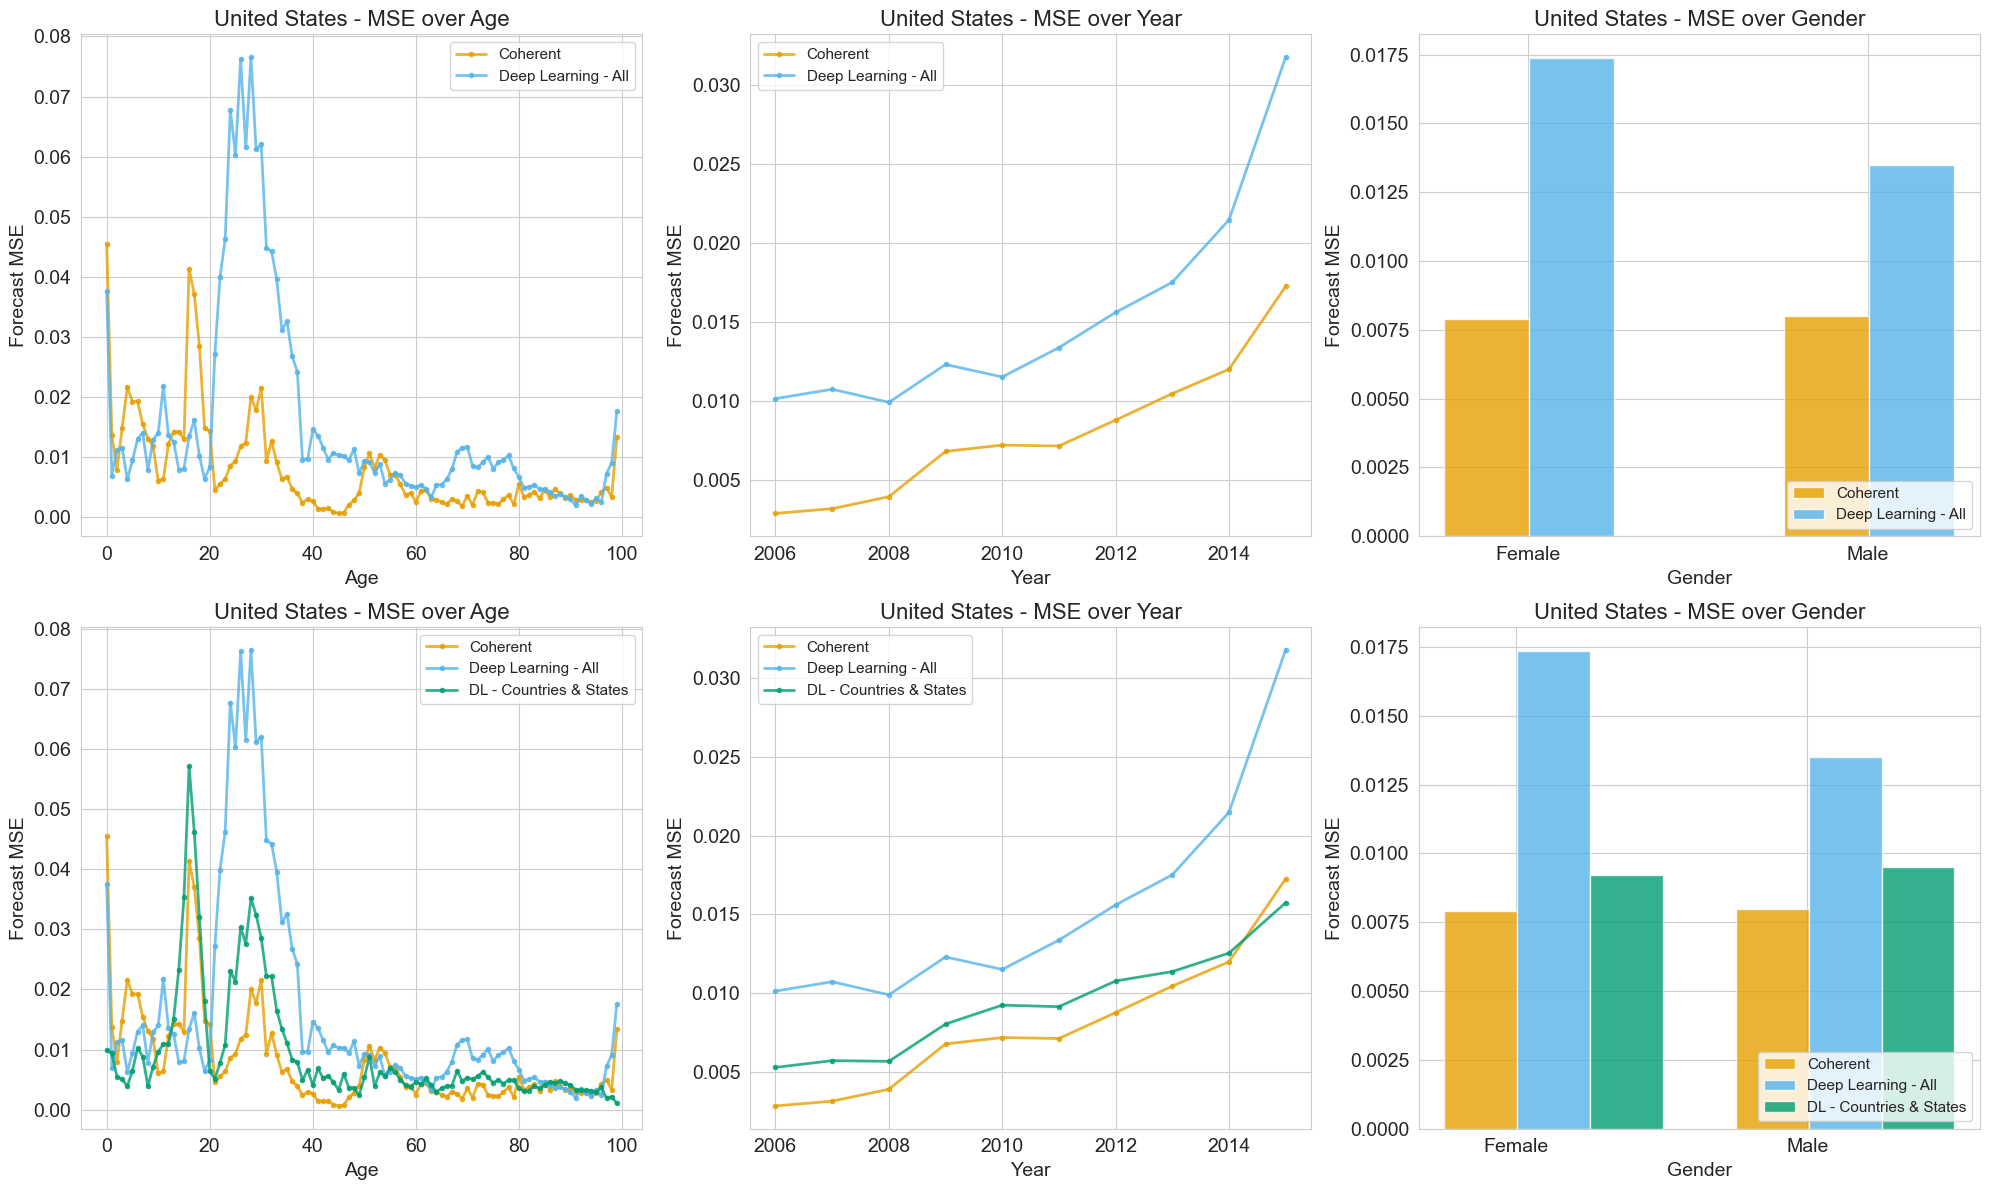

In [54]:
country_index = 39  # US
country_name = "United States"
features = {"Age": 3, "Year": 2, "Gender": 1}  
model_options = [{"Coherent": [c_test_divided], "Deep Learning - All": dl_test_divided}, {"Coherent": [c_test_divided], "Deep Learning - All": dl_test_divided, "DL - Countries & States": combined_test_divided}]

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=False)
axes = axes.flatten()

for m_idx, models in enumerate(model_options):
    for jdx, (feature_name, feature_index) in enumerate(features.items()):
        avg_mses = compute_avg_mses(country_index, feature_index, models)
        ax = axes[m_idx * len(features) + jdx] 
        

        for i, (label, data) in enumerate(avg_mses.items()):
            keys, values = zip(*sorted(data.items()))

            if feature_index == 1:  
                x = np.arange(len(keys)) + i * 0.25 
                ax.bar(x, values, width=0.25, label=label, alpha=0.8, color=palette[i])
                gender_labels = ['Female' if k == 0 else 'Male' for k in keys]
                ax.set_xticks(np.arange(len(keys)) + 0.12)
                ax.set_xticklabels(gender_labels)
                ax.legend(fontsize=11, loc='lower right', frameon=True)
            else:
                ax.plot(keys, values, label=label, linestyle='-', marker='o', 
                        markersize=3, linewidth=2, alpha=0.8, color=palette[i])
                ax.legend(fontsize=11, loc='best', frameon=True)
                ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

        ax.set_title(f"{country_name} - MSE over {feature_name}")
        ax.set_xlabel(feature_name)
        ax.set_ylabel("Forecast MSE")

plt.tight_layout()
plt.savefig("../figures/us_test_fig_jun.png", format="png", dpi=300, bbox_inches="tight")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})
plt.show()